# Task 2
# Sentiement Analysis with NLP
Name: Kalaiarashi S B

This project demonstrates about sentiment analysis with NLP using TF-IDF

## Importing libraries

In [1]:
import numpy as np
import pandas as pd

## Loading dataset

In [2]:
df=pd.read_csv("Restaurant_Reviews.tsv",sep='\t')

In [3]:
df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


## Preprocessing

In [6]:
df.isnull().sum()

,0
Review,0
Liked,0


In [7]:
x=df['Review']
y=df['Liked']

In [8]:
df['Review']

,Review
0,Wow... Loved this place.
1,Crust is not good.
2,Not tasty and the texture was just nasty.
3,Stopped by during the late May bank holiday of...
4,The selection on the menu was great and so wer...
...,...
995,I think food should have flavor and texture an...
996,Appetite instantly gone.
997,Overall I was not impressed and would not go b...
998,"The whole experience was underwhelming, and I ..."


In [16]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words=set(stopwords.words('english'))
def preprocess_text(text):
  text=text.lower()
  text=re.sub(r'[^a-zA-Z]',' ',text)
  words=text.split()
  words=[word for word in words if word not in stop_words]
  text=" ".join(words)
  return text
df['clean_review']=df['Review'].apply(preprocess_text)
print(df[['clean_review','Review']].head())


                                        clean_review  \
0                                    wow loved place   
1                                         crust good   
2                                tasty texture nasty   
3  stopped late may bank holiday rick steve recom...   
4                        selection menu great prices   

                                              Review  
0                           Wow... Loved this place.  
1                                 Crust is not good.  
2          Not tasty and the texture was just nasty.  
3  Stopped by during the late May bank holiday of...  
4  The selection on the menu was great and so wer...  


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## TD-IDF

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfid=TfidfVectorizer()
x=tfid.fit_transform(df['clean_review'])
print(x)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5389 stored elements and shape (1000, 1890)>
  Coords	Values
  (0, 1870)	0.7134952725687201
  (0, 964)	0.6028357327736888
  (0, 1230)	0.35709043016202086
  (1, 380)	0.895377322694293
  (1, 704)	0.44530826402032975
  (2, 1653)	0.5068726783980841
  (2, 1666)	0.6095408468238828
  (2, 1082)	0.6095408468238828
  (3, 964)	0.27171638832534173
  (3, 1592)	0.33577835169838083
  (3, 909)	0.33577835169838083
  (3, 1005)	0.30160229472270916
  (3, 103)	0.35577006345165846
  (3, 795)	0.35577006345165846
  (3, 1387)	0.35577006345165846
  (3, 1584)	0.35577006345165846
  (3, 1343)	0.32159400647598674
  (4, 1458)	0.554755288448251
  (4, 1027)	0.5082463503491902
  (4, 718)	0.36953218342901817
  (4, 1274)	0.5453239245674157
  (5, 686)	0.4168964713349544
  (5, 35)	0.5266822095095379
  (5, 1808)	0.3846461795862529
  (5, 391)	0.45980024279895326
  :	:
  (997, 1868)	0.4170585210781322
  (997, 697)	0.37954315223903046
  (997, 94)	0.3513962126194226


In [40]:
import pandas as pd

df_tfid = pd.DataFrame(
    x.toarray(),
    columns=tfid.get_feature_names_out()
)

print(df_tfid.head())

   absolute  absolutely  absolutley  accident  accommodations  accomodate  \
0       0.0         0.0         0.0       0.0             0.0         0.0   
1       0.0         0.0         0.0       0.0             0.0         0.0   
2       0.0         0.0         0.0       0.0             0.0         0.0   
3       0.0         0.0         0.0       0.0             0.0         0.0   
4       0.0         0.0         0.0       0.0             0.0         0.0   

   accordingly  accountant  ache  acknowledged  ...  years  yellow  \
0          0.0         0.0   0.0           0.0  ...    0.0     0.0   
1          0.0         0.0   0.0           0.0  ...    0.0     0.0   
2          0.0         0.0   0.0           0.0  ...    0.0     0.0   
3          0.0         0.0   0.0           0.0  ...    0.0     0.0   
4          0.0         0.0   0.0           0.0  ...    0.0     0.0   

   yellowtail  yelpers  yet  yucky  yukon  yum  yummy  zero  
0         0.0      0.0  0.0    0.0    0.0  0.0    0.0 

## Spliting training and test dataset

In [22]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


## LogisticRegression

In [24]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

## Prediction of dataset

In [26]:
pred=lr.predict(x_test)

In [36]:
output=['This product is amazing']
k=tfid.transform(output)
prediction=lr.predict(k)
print(prediction)

[1]


In [37]:
output=['This product is worst']
k=tfid.transform(output)
prediction=lr.predict(k)
print(prediction)

[0]


## Accuracy of the model

In [38]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,pred))

0.76


## Visualization

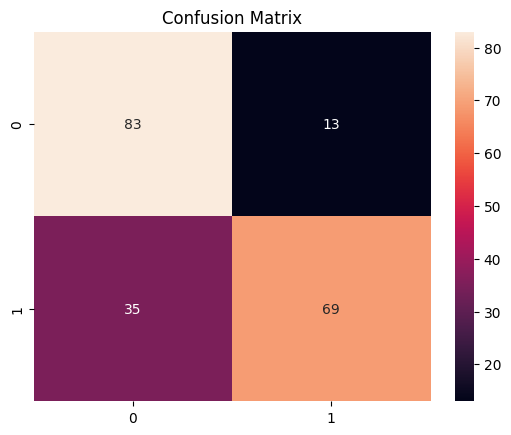

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.show()

## Key Insights

1. The model performs better at identifying negative reviews.

2. Positive reviews are sometimes misclassified as negative.

3. TF-IDF successfully extracted important textual features from customer reviews.

4. Logistic Regression proved effective for text classification tasks.

5. Text preprocessing improved model performance by reducing noise in the dataset.